In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import confusion_matrix

PLOTS_DIR = "plots"
RNG_SEED = 42
DATA_DIR = "data"

if not os.path.exists(PLOTS_DIR):
    os.makedirs(PLOTS_DIR)

np.random.seed(RNG_SEED)

In [119]:
def save_plot(fig, filename):
    fig_file_path = os.path.join(PLOTS_DIR, filename)
    fig.savefig(fig_file_path, dpi=300)

In [120]:
# labels are converted to integers to be able to use `np.bincount`
X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv", header=None).to_numpy()
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv", header=None).to_numpy().ravel().astype(int)
X_test  = pd.read_csv(f"{DATA_DIR}/X_test.csv",  header=None).to_numpy()
y_test  = pd.read_csv(f"{DATA_DIR}/y_test.csv",  header=None).to_numpy().ravel().astype(int)

print("X_train", X_train.shape)
print("y_train", y_train.shape)
print("X_test ", X_test.shape)
print("y_test ", y_test.shape)

labels = np.unique(y_train)
assert np.array_equal(labels, np.unique(y_test)), "Train and test labels do not match!"
print("Labels:", labels)

X_train (33724, 16)
y_train (33724,)
X_test  (13901, 16)
y_test  (13901,)
Labels: [0 1 2 3 4]


# 3.1 Data understanding and preprocessing

In [121]:
counts_train = np.bincount(y_train)
freq_train = counts_train / counts_train.sum()
print("Class frequencies:", freq_train)

Class frequencies: [0.52087534 0.09551062 0.25272803 0.04693986 0.08394615]


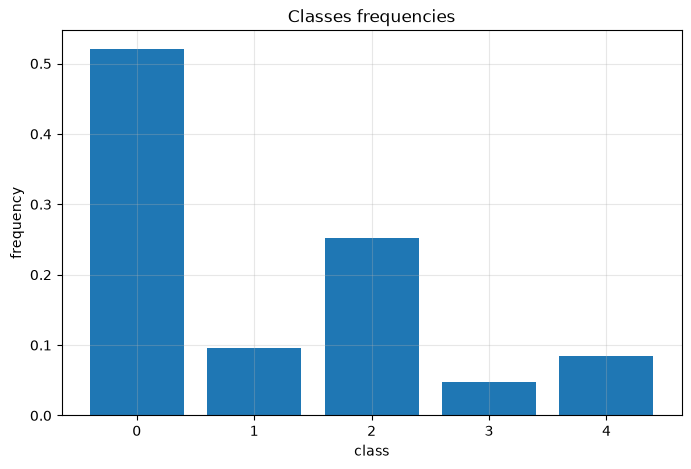

In [122]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(r"Classes frequencies")
ax.set_xlabel(r"class")
ax.set_ylabel(r"frequency")
ax.grid(alpha=0.3)
ax.bar(labels, freq_train)
plt.show()
save_plot(fig, "classes_freqs.png")

# 3.2.1 Logistic regression

In [123]:
lr = LogisticRegression(max_iter=150).fit(X_train, y_train)
lr_train_err = 1 - lr.score(X_train, y_train)
lr_test_err = 1 - lr.score(X_test, y_test)

print("Train err:", lr_train_err)
print("Test err: ", lr_test_err)

Train err: 0.14959672636697896
Test err:  0.09927343356593055


# 3.2.2 Random forest

In [124]:
for ntrees in [50, 100, 200]:
    rf = RandomForestClassifier(n_estimators=ntrees, random_state=RNG_SEED, oob_score=True).fit(X_train, y_train)
    rf_train_err = 1 - rf.score(X_train, y_train)
    rf_test_err = 1 - rf.score(X_test, y_test)
    rf_oob_err = 1 - rf.oob_score_

    print(f"----- Trees: {ntrees} -----")
    print("Train err:     ", rf_train_err)
    print("Test err:      ", rf_test_err)
    print("Out-of-bag err:", rf_oob_err)

----- Trees: 50 -----
Train err:      0.0003854821492111915
Test err:       0.11322926408172074
Out-of-bag err: 0.15187996678923021
----- Trees: 100 -----
Train err:      2.965247301622842e-05
Test err:       0.11006402417092298
Out-of-bag err: 0.14950776894793028
----- Trees: 200 -----
Train err:      0.0
Test err:       0.10992014962952301
Out-of-bag err: 0.14814375518918277


# 3.2.3 Nearest neighbor

In [142]:
ks = np.arange(1, 202, 2) # use only odd numbers to have less ties
cv = KFold(n_splits=5)

k_errs = []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_errs = 1 - cross_val_score(knn, X_train, y_train, cv=cv)
    k_errs.append(np.mean(cv_errs))

K_idx = np.argmin(k_errs)
K = ks[K_idx]
K_err = k_errs[K_idx]
print("K:", K)
print("Error:", K_err)

K: 185
Error: 0.16279105299211136


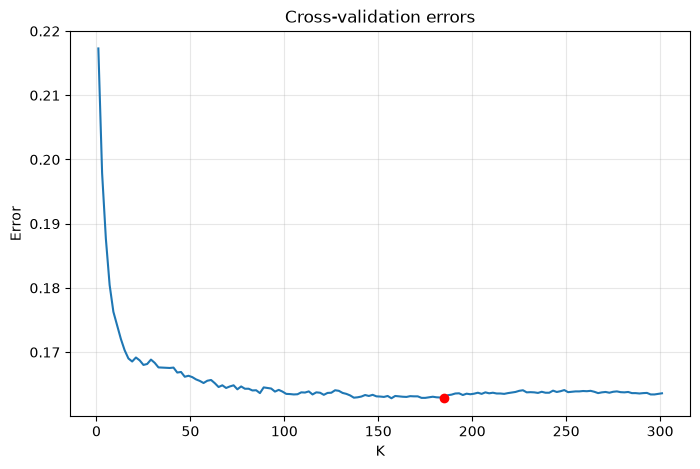

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(r"Cross-validation errors")
ax.set_xlabel(r"K")
ax.set_ylabel(r"Error")
ax.grid(alpha=0.3)
ax.plot(ks, k_errs)
ax.plot(K, K_err, "ro")
plt.show()
save_plot(fig, "cv_errs.png")

In [141]:
knn = KNeighborsClassifier(n_neighbors=K).fit(X_train, y_train)
knn_train_err = 1 - knn.score(X_train, y_train)
knn_test_err = 1 - knn.score(X_test, y_test)

print("Train err:", knn_train_err)
print("Test err: ", knn_test_err)

Train err: 0.150308385719369
Test err:  0.09574850730163298
